# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Verify Dataset

In [ ]:
import os

# Final dataset path
DATASET_PATH = "/content/drive/MyDrive/malware_project/final_dataset"

# Check dataset exists
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("Dataset path not found!")

print("✔ Dataset path found")

# List all class folders
class_folders = sorted(os.listdir(DATASET_PATH))

print("\nFINAL DATASET STRUCTURE:\n")

total_images = 0
benign_total = 0
malware_total = 0

for folder in class_folders:
    folder_path = os.path.join(DATASET_PATH, folder)
    img_count = len(os.listdir(folder_path))
    total_images += img_count

    if folder.startswith("benign"):
        benign_total += img_count
    elif folder.startswith("malware"):
        malware_total += img_count

    print(f"{folder:30s} -> {img_count:5d} images")

print("\n" + "-"*55)
print(f"TOTAL BENIGN IMAGES          -> {benign_total}")
print(f"TOTAL MALWARE IMAGES         -> {malware_total}")
print(f"TOTAL IMAGES (ALL)           -> {total_images}")
print("-"*55)

print("\n✔ Dataset verification completed successfully")

✔ Dataset path found

FINAL DATASET STRUCTURE:

benign_dll                     ->  9784 images
benign_exe                     ->     7 images
benign_mui                     ->    75 images
benign_other                   ->     4 images
malware_adialerc               ->   122 images
malware_agentfyi               ->   116 images
malware_allaplea               ->  2949 images
malware_allaplel               ->  1591 images
malware_aluerongen!j           ->   198 images
malware_autorunk               ->   106 images
malware_c2lopgen!g             ->   200 images
malware_c2lopp                 ->   146 images
malware_dialplatformb          ->   177 images
malware_dontovoa               ->   162 images
malware_fakerean               ->   381 images
malware_instantaccess          ->   431 images
malware_lolydaaa1              ->   213 images
malware_lolydaaa2              ->   184 images
malware_lolydaaa3              ->   123 images
malware_lolydaat               ->   159 images
malware_male

# Sanity & Corruption Check

In [ ]:
# ======================================
# STEP 2: Data Sanity & Corruption Check
# ======================================

from PIL import Image

corrupted_images = []
empty_folders = []

for folder in class_folders:
    folder_path = os.path.join(DATASET_PATH, folder)
    files = os.listdir(folder_path)

    # Check empty folders
    if len(files) == 0:
        empty_folders.append(folder)
        continue

    # Check corrupted images
    for file in files:
        file_path = os.path.join(folder_path, file)
        try:
            img = Image.open(file_path)
            img.verify()   # verify image integrity
        except:
            corrupted_images.append(file_path)

print("✔ Sanity check completed")

print("\nEmpty folders:", empty_folders if empty_folders else "None")

print("\nCorrupted images found:", len(corrupted_images))


✔ Sanity check completed

Empty folders: None

Corrupted images found: 0


# Preprocessing & Normalization

In [ ]:
# ======================================
# STEP 3: Preprocessing & Normalization
# ======================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    validation_split=0.2     # 80% train, 20% validation
)

# Training generator
train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",   # MULTI-CLASS
    color_mode="rgb",           # Required for pretrained models
    subset="training",
    shuffle=True
)

# Validation generator
val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    color_mode="rgb",
    subset="validation",
    shuffle=False
)

print("✔ Preprocessing & normalization completed")


Found 15379 images belonging to 29 classes.
Found 3830 images belonging to 29 classes.
✔ Preprocessing & normalization completed


# Class Mapping

In [ ]:
# ======================================
# STEP 4: Class Index Mapping
# ======================================

class_indices = train_data.class_indices

print("\nCLASS INDEX MAPPING:\n")

for class_name, idx in class_indices.items():
    print(f"{idx:2d} -> {class_name}")

print("\nTotal classes:", len(class_indices))



CLASS INDEX MAPPING:

 0 -> benign_dll
 1 -> benign_exe
 2 -> benign_mui
 3 -> benign_other
 4 -> malware_adialerc
 5 -> malware_agentfyi
 6 -> malware_allaplea
 7 -> malware_allaplel
 8 -> malware_aluerongen!j
 9 -> malware_autorunk
10 -> malware_c2lopgen!g
11 -> malware_c2lopp
12 -> malware_dialplatformb
13 -> malware_dontovoa
14 -> malware_fakerean
15 -> malware_instantaccess
16 -> malware_lolydaaa1
17 -> malware_lolydaaa2
18 -> malware_lolydaaa3
19 -> malware_lolydaat
20 -> malware_malexgen!j
21 -> malware_obfuscatorad
22 -> malware_rbot!gen
23 -> malware_skintrimn
24 -> malware_swizzorgen!e
25 -> malware_swizzorgen!i
26 -> malware_vbat
27 -> malware_wintrimbx
28 -> malware_yunera

Total classes: 29


# Visualize Preprocessed Images

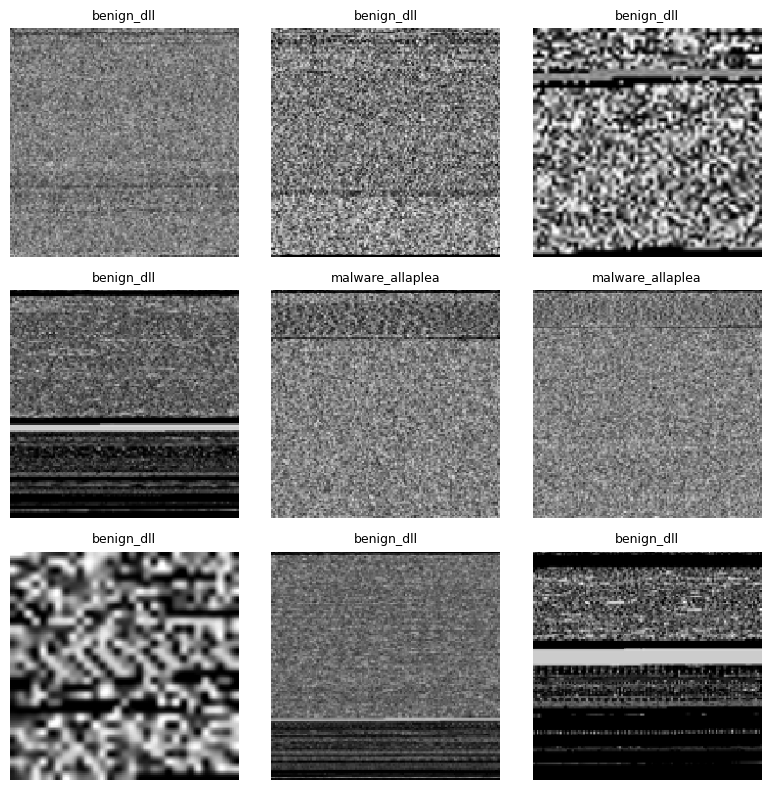

In [ ]:
# ======================================
# STEP 4B: Visual Sanity Check
# ======================================

import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_data)

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    class_id = np.argmax(labels[i])
    class_name = list(class_indices.keys())[list(class_indices.values()).index(class_id)]
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()
